<a href="https://colab.research.google.com/github/Nafeesatu/AI-bootcamp-portfolio/blob/main/Loan_Default_prediction_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Loan Default Prediction System**

# README for Loan Default Prediction System

This notebook focuses on building a loan default prediction system using a given dataset. The process involves several key steps:

1.  **Data Loading and Initial Inspection**: The raw loan dataset is loaded, and a preliminary examination of its structure, missing values, and descriptive statistics is performed.

2.  **Exploratory Data Analysis (EDA)**: Key features like `Credit_Score`, `rate_of_interest`, and their relationship with the `Status` (default) are visualized using KDE plots. Correlation heatmaps are used to understand the relationships between numerical features and the target variable.

3.  **Data Preprocessing**:
    *   One-hot encoding is applied to categorical features.
    *   Missing values in numerical features are handled using median imputation.
    *   The data is split into training and testing sets, with stratification to maintain the original class distribution.

4.  **Model Building and Evaluation**:
    *   A Logistic Regression model is trained on the preprocessed data.
    *   The initial model's performance is evaluated using accuracy and F1-score, highlighting challenges due to class imbalance.
    *   **Addressing Class Imbalance**: SMOTE (Synthetic Minority Over-sampling Technique) is applied to the training data to balance the classes. A Logistic Regression model is then retrained on the SMOTE-resampled data and re-evaluated.

## Dataset Description:
The dataset contains various features related to loan applications and their default status.

## Resources


In [2]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
sns.set_style('whitegrid')
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
#load the data
df = pd.read_csv('/content/Loan_Default.csv')

In [5]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758.0,CIB,25-34,to_inst,98.728814,south,direct,1.0,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552.0,EXP,55-64,to_inst,NaN,North,direct,1.0,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834.0,CIB,35-44,to_inst,80.019685,south,direct,0.0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587.0,CIB,45-54,not_inst,69.376900,North,direct,0.0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602.0,EXP,25-34,not_inst,91.886544,North,direct,0.0,39.0


In [6]:
df.shape

(131410, 34)

In [7]:
df.isnull().sum().sum()

np.int64(160047)

In [8]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,131410.000000,131410.0,1.314100e+05,99192.000000,99017.000000,96374.000000,131370.000000,1.180910e+05,123333.000000,131409.000000,118091.000000,131409.000000,110127.000000
mean,90594.500000,2019.0,3.307595e+05,4.045736,0.442639,3228.556341,335.099604,4.973640e+05,6947.082776,699.730681,72.774112,0.246498,37.754765
std,37934.943774,0.0,1.837330e+05,0.561271,0.513204,3249.683351,58.450598,3.609224e+05,6539.953711,115.940056,41.943744,0.430973,10.527200
min,24890.000000,2019.0,1.165000e+03,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,57742.250000,2019.0,1.965000e+05,3.625000,0.076600,583.247500,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,90594.500000,2019.0,2.965000e+05,3.990000,0.391000,2601.285000,360.000000,4.180000e+05,5700.000000,699.000000,75.135870,0.000000,39.000000
75%,123446.750000,2019.0,4.365000e+05,4.375000,0.776700,4821.485000,360.000000,6.180000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,156299.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


Object `default` not found.
Default rate: 24.6%


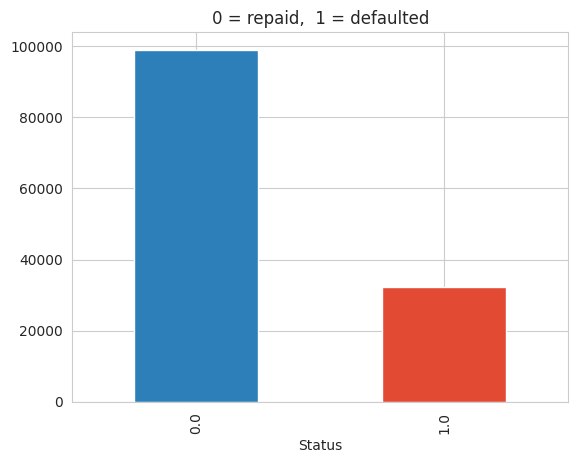

In [14]:
Target balance — what % actually default?
rate = df['Status'].mean()
print(f'Default rate: {rate:.1%}')
df['Status'].value_counts().plot(kind='bar', color=['#2c7fb8','#e34a33'])
plt.title('0 = repaid,  1 = defaulted'); plt.show()
# NOTE: only ~25% default. The data is imbalanced — keep an eye on F1, not just accuracy.

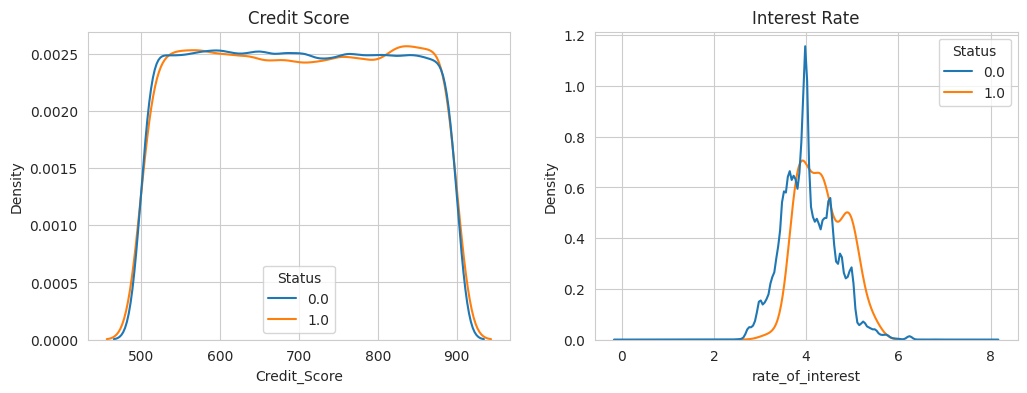

In [17]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.kdeplot(data=df, x='Credit_Score', hue='Status', common_norm=False, ax=ax[0])
ax[0].set_title('Credit Score')
sns.kdeplot(data=df, x='rate_of_interest', hue='Status', common_norm=False, ax=ax[1])
ax[1].set_title('Interest Rate')
plt.show()

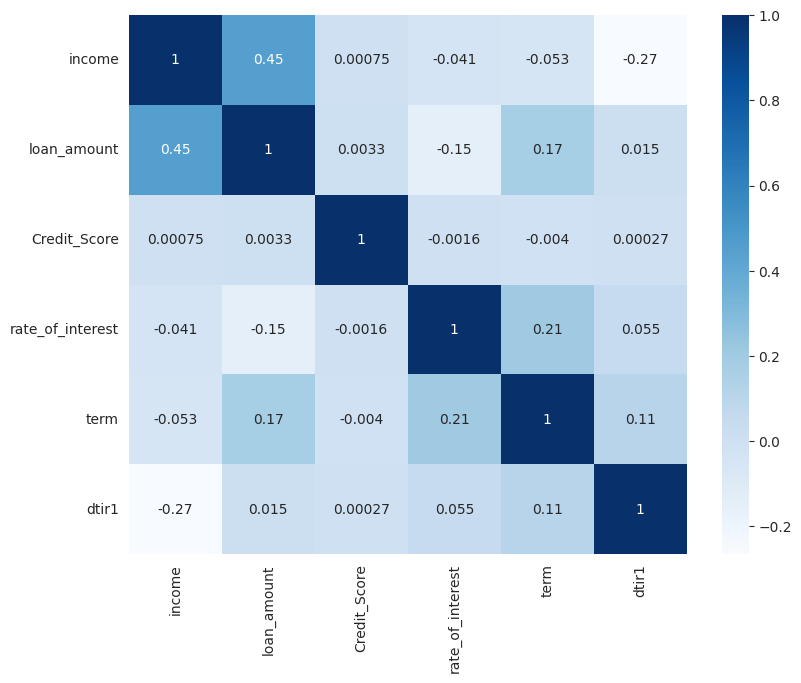

In [20]:
# correlation
num = ['income','loan_amount','Credit_Score','rate_of_interest',
       'term','dtir1']
plt.figure(figsize=(9,7))
sns.heatmap(df[num].corr(), annot=True, cmap='Blues')
plt.show()

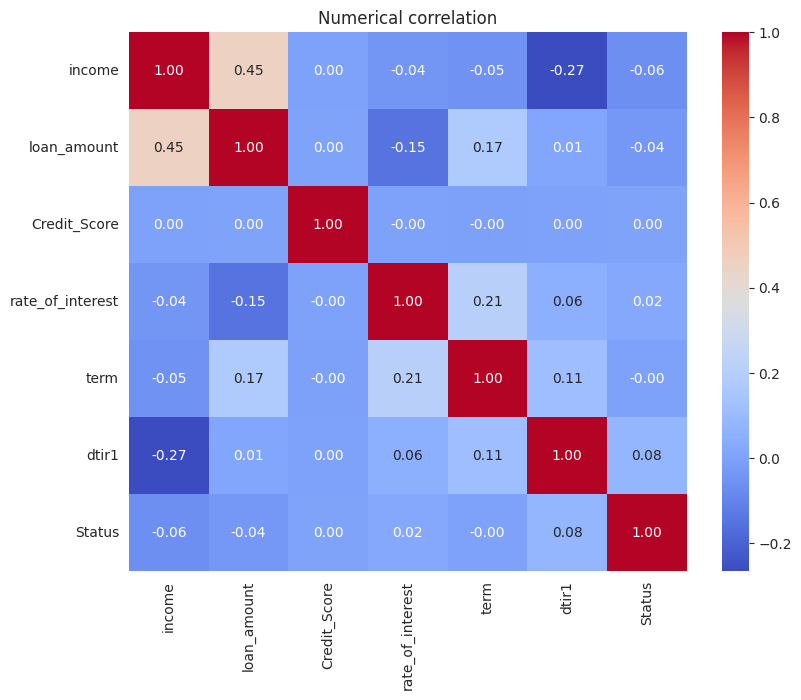

In [27]:
num = ['income','loan_amount','Credit_Score','rate_of_interest',
       'term','dtir1']
plt.figure(figsize=(9,7))
sns.heatmap(df[num+['Status']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Numerical correlation'); plt.show()

In [23]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758.0,CIB,25-34,to_inst,98.728814,south,direct,1.0,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552.0,EXP,55-64,to_inst,NaN,North,direct,1.0,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834.0,CIB,35-44,to_inst,80.019685,south,direct,0.0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587.0,CIB,45-54,not_inst,69.376900,North,direct,0.0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602.0,EXP,25-34,not_inst,91.886544,North,direct,0.0,39.0



**One-hot encoding**


In [34]:
# One-hot encode all text columns
df_enc = pd.get_dummies(df, drop_first=True)

# Drop rows where 'Status' is NaN first, as it's the target variable
df_enc.dropna(subset=['Status'], inplace=True)

# Impute remaining numerical NaNs in feature columns with their median
# Select only numerical columns for imputation, excluding the 'Status' column (which is now clean)
numerical_feature_cols = df_enc.select_dtypes(include=np.number).columns.drop('Status', errors='ignore')
for col in numerical_feature_cols:
    if df_enc[col].isnull().any():
        df_enc[col] = df_enc[col].fillna(df_enc[col].median())

X = df_enc.drop(columns=['Status'])
y = df_enc['Status']

# Print value counts to verify class distribution after preprocessing
print("Value counts for y before split:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('Train:', X_train.shape, ' Test:', X_test.shape)
print("Value counts for y_train after split:")
print(y_train.value_counts())

Value counts for y before split:
Status
0.0    99017
1.0    32392
Name: count, dtype: int64
Train: (105127, 50)  Test: (26282, 50)
Value counts for y_train after split:
Status
0.0    79213
1.0    25914
Name: count, dtype: int64


**MODEL BUILDING**

In [35]:
from sklearn.linear_model import LogisticRegression

#Train a Logistic Regression model
log_reg_model = LogisticRegression(random_state=42,solver='liblinear') #liblinear is good for small data
log_reg_model.fit(X_train, y_train)

#make prediction on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

#evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

print(f'Logistic Regression Accuracy: {accuracy_log_reg:.4f}')
print(f'Logistic Regression F1 Score: {f1_log_reg:.4f}')

Logistic Regression Accuracy: 0.7536
Logistic Regression F1 Score: 0.0003


**Addressing Class Imbalance with SMOTE and Retraining Logistic Regression**

In [37]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Value counts for y_train after SMOTE:")
print(y_train_smote.value_counts())

# Retrain Logistic Regression model with SMOTE data
log_reg_model_smote = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000) # Increased max_iter for convergence
log_reg_model_smote.fit(X_train_smote, y_train_smote)

# Make predictions on the original (unbalanced) test set
y_pred_log_reg_smote = log_reg_model_smote.predict(X_test)

# Evaluate the model
accuracy_log_reg_smote = accuracy_score(y_test, y_pred_log_reg_smote)
f1_log_reg_smote = f1_score(y_test, y_pred_log_reg_smote)

print(f'\nLogistic Regression (SMOTE) Accuracy: {accuracy_log_reg_smote:.4f}')
print(f'Logistic Regression (SMOTE) F1 Score: {f1_log_reg_smote:.4f}')

Value counts for y_train after SMOTE:
Status
0.0    79213
1.0    79213
Name: count, dtype: int64

Logistic Regression (SMOTE) Accuracy: 0.5589
Logistic Regression (SMOTE) F1 Score: 0.4531


**Inspecting Data types and Missing Values**

In [36]:
print('DataFrame Info:')
df.info()
print('\nMissing values per column:')
print(df.isnull().sum().sort_values(ascending=False))

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131410 entries, 0 to 131409
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         131410 non-null  int64  
 1   year                       131410 non-null  int64  
 2   loan_limit                 128441 non-null  object 
 3   Gender                     131410 non-null  object 
 4   approv_in_adv              130596 non-null  object 
 5   loan_type                  131410 non-null  object 
 6   loan_purpose               131298 non-null  object 
 7   Credit_Worthiness          131410 non-null  object 
 8   open_credit                131410 non-null  object 
 9   business_or_commercial     131410 non-null  object 
 10  loan_amount                131410 non-null  int64  
 11  rate_of_interest           99192 non-null   float64
 12  Interest_rate_spread       99017 non-null   float64
 13  Upfront_charg